In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Video profile metrics
mrbeast_data = {
    'Video_Title': [
        '1,000 Blind People See For The First Time',
        'I Survived 50 Hours In Antarctica',
        'Last To Leave Ferris Wheel Wins $20,000',
        '100 Kids Vs 100 Adults For $500,000',
        'I Bought A Chocolate Factory!',
        'Would You Swim With Sharks For $100,000?',
        'I Survived A Meteor Strike?',
        'World’s Most Dangerous Escape Room!'
    ],
    'Content_Type' : ['Philanthropy', 'Survival', 'Challenge', 'Challenge', 'Vlog', 'Challenge', 'Survival', 'Challenge'],
    'Views_Millions' : [185.0, 210.0, 92.0, 145.0, np.nan, 125.0, 80.0, 160.0], # Notice the NaN here
    'Likes_Millions' : [11.0, 12.5, 4.1, np.nan, 6.2, 5.8, 3.9, 7.1], # And another NaN here
    'Est_Sponsor_Paid_USD' : [1200000, 1500000, 600000, 950000, 800000, 750000, 0, 1100000]
}

df_beast = pd.DataFrame(mrbeast_data)
df_beast

,Video_Title,Content_Type,Views_Millions,Likes_Millions,Est_Sponsor_Paid_USD
0,"1,000 Blind People See For The First Time",Philanthropy,185.0,11.0,1200000
1,I Survived 50 Hours In Antarctica,Survival,210.0,12.5,1500000
2,"Last To Leave Ferris Wheel Wins $20,000",Challenge,92.0,4.1,600000
3,"100 Kids Vs 100 Adults For $500,000",Challenge,145.0,NaN,950000
4,I Bought A Chocolate Factory!,Vlog,NaN,6.2,800000
5,"Would You Swim With Sharks For $100,000?",Challenge,125.0,5.8,750000
6,I Survived A Meteor Strike?,Survival,80.0,3.9,0
7,World’s Most Dangerous Escape Room!,Challenge,160.0,7.1,1100000


In [13]:
# Print sum of all the null values for every column
print(df_beast.isnull().sum())

Video_Title             0
Content_Type            0
Views_Millions          1
Likes_Millions          1
Est_Sponsor_Paid_USD    0
dtype: int64


In [14]:
# MrBeast's dataset has a missing value in the views column. So calculating the mean of the views and replacing with Nan
mean_views = df_beast['Views_Millions'].mean()
df_beast['Views_Millions'] = df_beast['Views_Millions'].fillna(mean_views) # .fillna() fill null values
df_beast

,Video_Title,Content_Type,Views_Millions,Likes_Millions,Est_Sponsor_Paid_USD
0,"1,000 Blind People See For The First Time",Philanthropy,185.000000,11.0,1200000
1,I Survived 50 Hours In Antarctica,Survival,210.000000,12.5,1500000
2,"Last To Leave Ferris Wheel Wins $20,000",Challenge,92.000000,4.1,600000
3,"100 Kids Vs 100 Adults For $500,000",Challenge,145.000000,NaN,950000
4,I Bought A Chocolate Factory!,Vlog,142.428571,6.2,800000
5,"Would You Swim With Sharks For $100,000?",Challenge,125.000000,5.8,750000
6,I Survived A Meteor Strike?,Survival,80.000000,3.9,0
7,World’s Most Dangerous Escape Room!,Challenge,160.000000,7.1,1100000


In [15]:
# Dropping row in 'Likes_Millions' which has a missing value
df_beast.dropna(subset = ['Likes_Millions'], inplace = True) # .dropna() drop null values
# the 'subset' argument tells Pandas: "Don't look at the whole table. Only look inside the 'Likes_Millions' column. If you find a missing value in other columns (like Views), ignore it. Only trigger the deletion if a row has an empty slot in the Likes column.
df_beast

,Video_Title,Content_Type,Views_Millions,Likes_Millions,Est_Sponsor_Paid_USD
0,"1,000 Blind People See For The First Time",Philanthropy,185.000000,11.0,1200000
1,I Survived 50 Hours In Antarctica,Survival,210.000000,12.5,1500000
2,"Last To Leave Ferris Wheel Wins $20,000",Challenge,92.000000,4.1,600000
4,I Bought A Chocolate Factory!,Vlog,142.428571,6.2,800000
5,"Would You Swim With Sharks For $100,000?",Challenge,125.000000,5.8,750000
6,I Survived A Meteor Strike?,Survival,80.000000,3.9,0
7,World’s Most Dangerous Escape Room!,Challenge,160.000000,7.1,1100000


In [16]:
# Creating a new column named 'Like_To_View_Ratio' which calculate the engagement metric for each video
df_beast['Like_To_View_Ratio'] = df_beast['Likes_Millions'] / df_beast['Views_Millions']
df_beast

,Video_Title,Content_Type,Views_Millions,Likes_Millions,Est_Sponsor_Paid_USD,Like_To_View_Ratio
0,"1,000 Blind People See For The First Time",Philanthropy,185.000000,11.0,1200000,0.059459
1,I Survived 50 Hours In Antarctica,Survival,210.000000,12.5,1500000,0.059524
2,"Last To Leave Ferris Wheel Wins $20,000",Challenge,92.000000,4.1,600000,0.044565
4,I Bought A Chocolate Factory!,Vlog,142.428571,6.2,800000,0.043531
5,"Would You Swim With Sharks For $100,000?",Challenge,125.000000,5.8,750000,0.046400
6,I Survived A Meteor Strike?,Survival,80.000000,3.9,0,0.048750
7,World’s Most Dangerous Escape Room!,Challenge,160.000000,7.1,1100000,0.044375


In [17]:
# Check the diversity of MrBeast's content styles.
print('Number of unique content styles:', df_beast['Content_Type'].nunique()) # gives number (HOW MANY)
print('Content Categories:', df_beast['Content_Type'].unique()) # gives actual categories (WHAT)

Number of unique content styles: 4
Content Categories: <StringArray>
['Philanthropy', 'Survival', 'Challenge', 'Vlog']
Length: 4, dtype: str


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


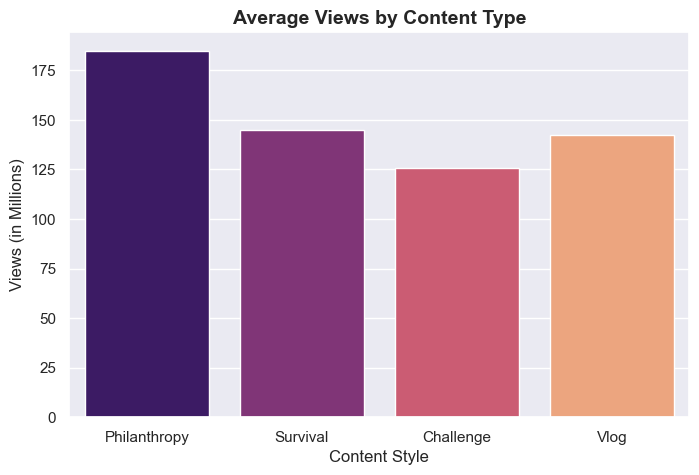

In [31]:
sns.set_theme(style = 'darkgrid')

# Canvas window size
plt.figure(figsize = (8,5))

sns.barplot(data = df_beast, 
            x = 'Content_Type', 
            y = 'Views_Millions', 
            hue = 'Content_Type', 
            palette = 'magma', 
            legend = False, # Don't show which color bar representing what?
            errorbar = None)

# Custom Titles
plt.title('Average Views by Content Type', fontsize = 14, fontweight = 'bold')
plt.xlabel('Content Style')
plt.ylabel('Views (in Millions)')

plt.show()

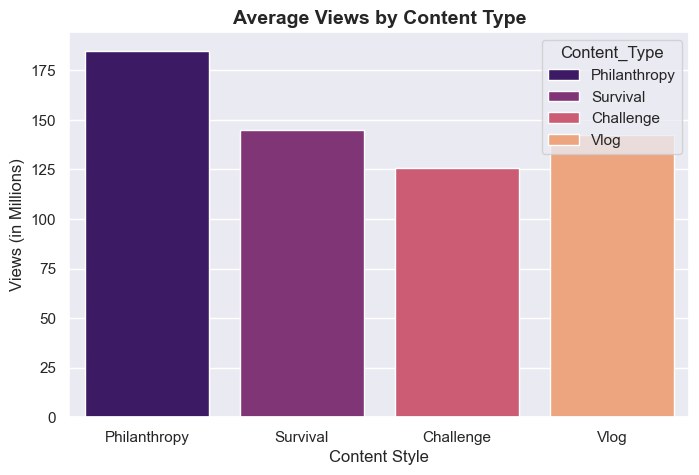

In [32]:
sns.set_theme(style = 'darkgrid')

# Canvas window size
plt.figure(figsize = (8,5))

sns.barplot(data = df_beast, 
            x = 'Content_Type', 
            y = 'Views_Millions', 
            hue = 'Content_Type', 
            palette = 'magma', 
            legend = True, # Shows which color bar representing what?
            errorbar = None)

# Custom Titles
plt.title('Average Views by Content Type', fontsize = 14, fontweight = 'bold')
plt.xlabel('Content Style')
plt.ylabel('Views (in Millions)')

plt.show()

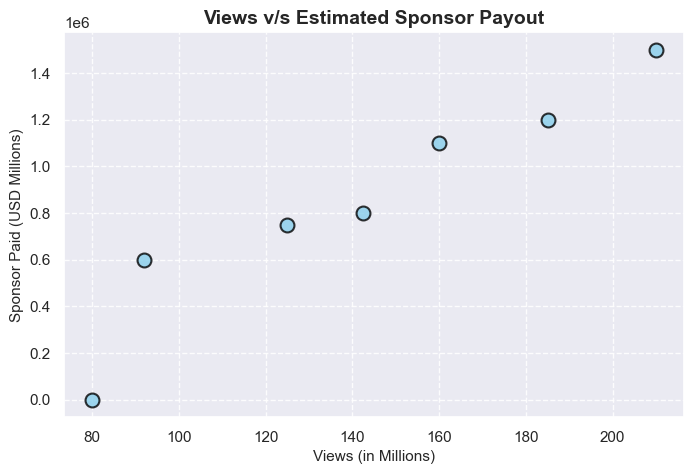

In [34]:
plt.figure(figsize = (8,5))

# Scatter Plot
plt.scatter(
    df_beast['Views_Millions'], 
    df_beast['Est_Sponsor_Paid_USD'],
    color = 'skyblue', 
    s = 100, # 's' is size of dots and 'alpha' is opacity of dots.
    alpha = 0.8, 
    edgecolor = 'black', 
    linewidth = 1.5) 

# Customize chart layout
plt.title('Views v/s Estimated Sponsor Payout', fontsize = 14, fontweight = 'bold')
plt.xlabel('Views (in Millions)', fontsize = 11)
plt.ylabel('Sponsor Paid (USD Millions)', fontsize = 11)

# Add a dashed background grid line to make values easy to read
plt.grid(True, linestyle = '--', alpha = 0.9)

plt.show()